In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/kaggle/input/hand-0/filtered_data.csv")

In [5]:
X = df[["x", "y"]]
kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster"] = kmeans.fit_predict(X)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [6]:
df['velocity'] = np.sqrt((df['x'].diff()/0.033)**2 + (df['y'].diff()/0.033)**2)
df.to_csv("/kaggle/working/updated_data.csv", index=False)

In [7]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,frame,hand_id,x,y,z,cluster,velocity
0,141.0,0.0,0.445243,0.745886,-0.006517,0,NaN
1,142.0,0.0,0.442835,0.745499,-0.005958,0,0.073887
2,143.0,0.0,0.443038,0.747222,-0.006862,0,0.052562
3,144.0,0.0,0.445860,0.746545,-0.007236,0,0.087943
4,145.0,0.0,0.444301,0.750504,-0.006540,0,0.128938


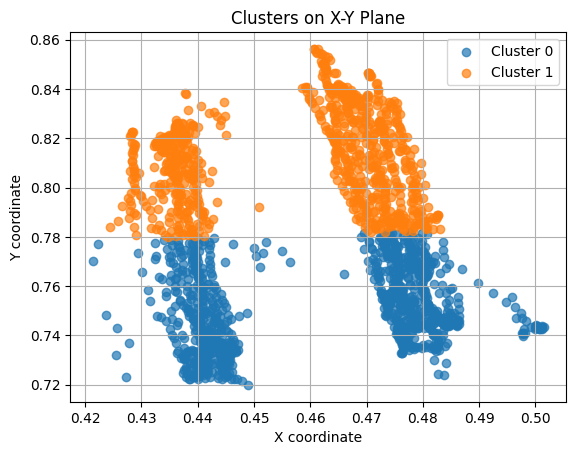

In [8]:
for cluster_id in df['cluster'].unique():
    cluster_data = df[df['cluster'] == cluster_id]
    plt.scatter(cluster_data['x'], cluster_data['y'], label=f'Cluster {cluster_id}', alpha=0.7)

# Step 4: Customize
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Clusters on X-Y Plane")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
df['velocity'] = np.sqrt((df['x'].diff()/0.033)**2 + (df['y'].diff()/0.033)**2)
df.to_csv("/kaggle/working/updated_data.csv", index=False)

In [31]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,frame,hand_id,x,y,z,cluster,velocity
0,141.0,0.0,0.445243,0.745886,-0.006517,0,NaN
1,142.0,0.0,0.442835,0.745499,-0.005958,0,0.073887
2,143.0,0.0,0.443038,0.747222,-0.006862,0,0.052562
3,144.0,0.0,0.445860,0.746545,-0.007236,0,0.087943
4,145.0,0.0,0.444301,0.750504,-0.006540,0,0.128938


In [10]:
df = df.dropna(subset=['velocity'])

X = df[["velocity", "y"]]
kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster2"] = kmeans.fit_predict(X)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


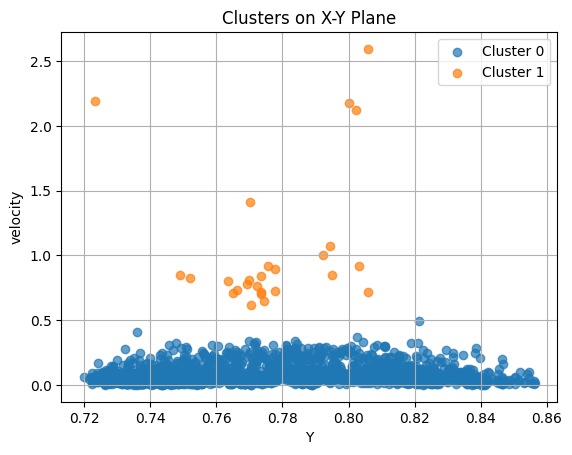

In [11]:
for cluster_id in df['cluster2'].unique():
    cluster_data = df[df['cluster2'] == cluster_id]
    plt.scatter(cluster_data['y'], cluster_data['velocity'], label=f'Cluster {cluster_id}', alpha=0.7)

# Step 4: Customize
plt.xlabel("Y")
plt.ylabel("velocity")
plt.title("Clusters on X-Y Plane")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
df = df.dropna(subset=['velocity'])

X = df[["velocity", "x"]]
kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster3"] = kmeans.fit_predict(X)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


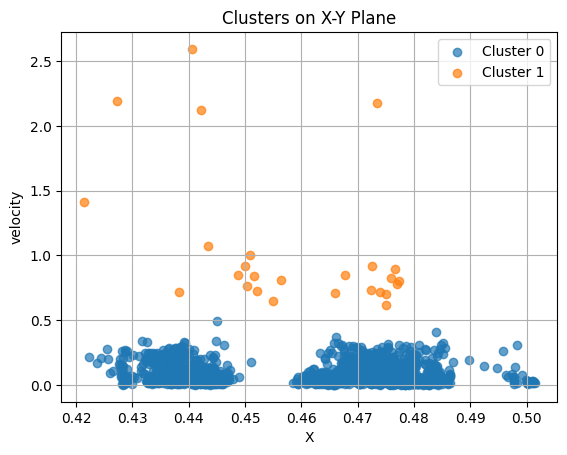

In [13]:
for cluster_id in df['cluster2'].unique():
    cluster_data = df[df['cluster2'] == cluster_id]
    plt.scatter(cluster_data['x'], cluster_data['velocity'], label=f'Cluster {cluster_id}', alpha=0.7)

# Step 4: Customize
plt.xlabel("X")
plt.ylabel("velocity")
plt.title("Clusters on X-Y Plane")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
df = df.dropna(subset=['velocity'])

X = df[["velocity", "x", "y"]]
kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster4"] = kmeans.fit_predict(X)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [15]:
from sklearn.decomposition import PCA

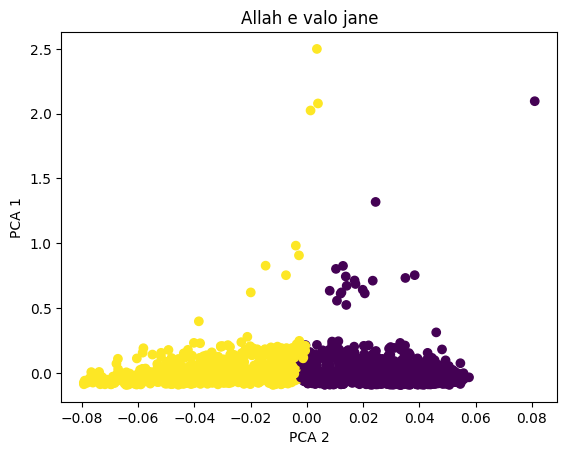

In [21]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df[["velocity", "x", "y"]])

plt.scatter(X_pca[:,1], X_pca[:,0], c=df["cluster"])
plt.xlabel("PCA 2")
plt.ylabel("PCA 1")
plt.title("Allah e valo jane")
plt.show()

In [19]:
print(X_pca)

[[-0.02056057  0.03225009]
 [-0.04186362  0.03025961]
 [-0.00651834  0.03137954]
 ...
 [-0.06565362  0.03989584]
 [-0.08596623  0.03970302]
 [-0.07947609  0.0392877 ]]
